In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")

In [2]:
from ctt.bases import make_canonical_polynomials, make_fourier, make_legendre_polynomials, make_chebyshev_polynomials

d = 3
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_legendre_polynomials(dim=n_features)
# basis = make_chebyshev_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# basis = lambda x: jnp.asarray([1., jax.nn.leaky_relu(x)])
key = random.PRNGKey(42)

In [3]:
from ctt.model import make_ctt

def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # return jnp.hstack((jnp.zeros((1,)), x))
    return x

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
ctt = make_ctt(lift, retraction, basis, d)
bases = [basis]*d_lift

In [4]:
from ctt.tt import tt_randn

key, *control_keys = random.split(key, 2+1)

target_ranks = [d_lift] + [2]*(d_lift-1) + [1]
target_tts = [
    tt_randn(control_key, [n_features] * d_lift, target_ranks, cov=3.0)
    for control_key in control_keys
]
target_ctt = make_ctt(lift, retraction, basis, d)

Sigma = random.normal(key=key, shape=(d, d))
Sigma = Sigma @ Sigma.T / d

TARGET_FUNCTION = "bivariate"

@jax.jit
def target(x: Float[Array, "d"]) -> Float[Array, "m"]:
    if TARGET_FUNCTION == "standard-gaussian":
        val = jnp.exp(-jnp.sum(x**2) / 2)
    elif TARGET_FUNCTION == "heaviside":
        val = jnp.prod((x >= 0.0) * 1.0)
    elif TARGET_FUNCTION == "recovery":
        val = target_ctt(target_tts, x)
    elif TARGET_FUNCTION == "gaussian":
        val = jax.scipy.stats.multivariate_normal.pdf(
            x=x, mean=jnp.zeros_like(x), cov=Sigma
        )
    elif TARGET_FUNCTION == "henon-heiles":
        val = (
            0.5 * jnp.sum(x**2)
            + 0.2 * jnp.sum(x[:-1] * x[1:] ** 2 - x[:-1] ** 3)
            + 0.2**2 / 16 * jnp.sum((x[:-1] ** 2 + x[1:] ** 2) ** 2)
        )
    elif TARGET_FUNCTION == "bivariate":
        val = jnp.sum((x[:d//2] + x[d//2:]) ** 2) / (4*d)
    elif TARGET_FUNCTION == "hyperbolic":
        val = 1./(1.+jnp.prod(x))
    return jnp.atleast_1d(val)



In [32]:
from ctt.tt import validate_ranks

key, train_key, val_key = random.split(key, 3)

domain = (-1., 1.)
N_train = 100_000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=domain[0], maxval=domain[1])
# X_train = random.normal(key=train_key, shape=(N_train, d))
y_train = jax.vmap(target)(X_train)

N_val = 2000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=domain[0], maxval=domain[1])
# X_val = random.normal(key=val_key, shape=(N_val, d))
y_val = jax.vmap(target)(X_val)

num_steps = 2
rank = 3
ranks = [d_lift] + [rank]*(d_lift-1) + [1]
ranks = validate_ranks([n_features]*d_lift, ranks)

In [33]:
def dataloader(arrays: list, batch_size: int, *, key: PRNGKeyArray):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = random.permutation(key, indices)
        (key,) = random.split(key, 1)
        start = 0
        end = batch_size
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [34]:
import optax
from ctt.tt import tt_norm, TT

@jax.jit
def compute_loss(tts: list[TT],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d_o"]) -> float:
    B = x.shape[0]
    y_pred = jax.vmap(ctt, in_axes=(None, 0))(tts, x)
    loss = jnp.sum((y_pred - y)**2) / B
    return 0.5*loss

@jax.jit
def grad_loss(y_hat: Float[Array, "B d_o"], y: Float[Array, "B d_o"]) -> Float[Array, "B d_o"]:
    # return y_hat - y
    return (y_hat - y) / y_hat.shape[0]

In [35]:
from ctt.tt import tt_orthogonalize

def left_orth(tt: TT) -> TT:
    U, V, S = tt_orthogonalize(tt)
    return [S[0]] + V

# Natural gradient descent

In [36]:
from functools import partial
from ctt.ngd import ctt_natural_grad, ctt_apply_updates, ctt_linesearch
from ctt.tt import tt_mul_scalar, tt_cp_dot

def ngd(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
        val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
        params: list[TT],
        opt_steps: int,
        training_key: PRNGKeyArray,
        batch_size: int = 64,
        l2_regularization: float = None) -> tuple[list[TT], tuple[list[float], list[float]], list[float]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    train_losses = []
    val_losses = []
    learning_rates = []

    ls_init_fn, ls_update_fn = ctt_linesearch(max_backtracking_steps=20,
                                              condition="armijo",
                                              increase_factor=1.5,
                                              decrease_factor=0.8,
                                              atol=0.)
    state = ls_init_fn(params)

    compute_natural_grads, compute_grads = ctt_natural_grad(bases,
                                                            lift,
                                                            retraction,
                                                            grad_loss)

    @jax.jit
    def step(tts: list[TT],
             x: Float[Array, "B d"],
             y: Float[Array, "B d_o"],
             state,
             key: PRNGKeyArray):
        # it should not be the gradient given by the autodiff, but rather the functional gradient
        loss = compute_loss(tts, x, y)
        natural_grads = compute_natural_grads(key, tts, x, y=y, l2_regularization=l2_regularization)
        direction = list(map(partial(tt_mul_scalar, val=-1.), natural_grads))

        # def _grad(params: list[TT], y: Float[Array, "B d_o"]) -> list[TT]:
        #     grads = compute_grads(params, x, y=y)
        #     # contract the first two cores
        #     grads = [
        #         [jnp.einsum("ijk,kmn->jmn", tt[0], tt[1])] + tt[2:]
        #         for tt in grads
        #     ]
        #     return grads
        def _compute_slope(dir: list[TT],
                           params: list[TT]) -> float:
            grads = compute_grads(params, x, y=y)
            # contract `dir` with `\nabla f(x_k)`
            slopes = [
                tt_cp_dot(dir[i], grads[i])
                for i in range(len(dir))
            ]
            return sum(slopes)

        # updates, state = ls_update_fn(direction, state, tts,
        #                               value=loss,
        #                               grad=_grad(tts, y=y),
        #                               value_fn=partial(compute_loss, x=x),
        #                               grad_fn=_grad,
        #                               y=y)
        updates, state = ls_update_fn(updates=direction,
                                      state=state,
                                      params=tts,
                                      slope_fn=_compute_slope,
                                      value=loss,
                                      value_fn=compute_loss,
                                      x=x,
                                      y=y)

        params = ctt_apply_updates(tts, updates)
        params = list(map(left_orth, params))
        return state, params, loss
    
    training_key, loader_key, ngd_key = random.split(training_key, 3)
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=loader_key)):
        state, params, loss = step(params, x, y, state, ngd_key)
        training_key, ngd_key = random.split(training_key)

        learning_rates.append(state.learning_rate)
        val_loss = compute_loss(params, X_val, y_val)
        train_losses.append(loss)
        val_losses.append(val_loss)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {loss:.3e} | Val loss: {val_loss:.3e} | Decrease: {loss-state.value:.3e}")

    return params, (train_losses, val_losses), learning_rates

In [37]:
import math
from ctt.tt import tt_zeros, tt_randn, tt_rand, tt_mul_scalar

key, *control_keys = random.split(key, num_steps+1)
key, training_key = random.split(key)

init_controls = [
    tt_mul_scalar(tt_randn(control_key, [n_features] * d_lift, ranks), math.sqrt(2/(num_steps*n_features**d_lift)))
    for control_key in control_keys
]
init_controls = list(map(left_orth, (init_controls)))
zero_init_controls = [
    tt_zeros([n_features] * d_lift, ranks)
    for _ in range(num_steps)
]
# init_controls = list(map(left_orth, init_controls))
print(list(map(tt_norm, init_controls)))

[Array(2.26777622, dtype=float64), Array(3.12967594, dtype=float64)]


In [38]:
params, (train_losses, val_losses), learning_rates = ngd(train_dataset=(X_train, y_train),
                                         val_dataset=(X_val, y_val),
                                         params=init_controls,
                                         opt_steps=20_000,
                                         training_key=training_key,
                                         batch_size=256,
                                         l2_regularization=1e-4)

Iter 0 | Loss: 2.256e+00 | Val loss: 2.091e+00 | Decrease: 1.865e-02
Iter 5 | Loss: 2.219e+00 | Val loss: 1.966e+00 | Decrease: 2.751e-02
Iter 10 | Loss: 1.941e+00 | Val loss: 1.851e+00 | Decrease: 2.009e-02
Iter 15 | Loss: 1.959e+00 | Val loss: 1.737e+00 | Decrease: 2.472e-02
Iter 20 | Loss: 1.590e+00 | Val loss: 1.634e+00 | Decrease: 2.045e-02
Iter 25 | Loss: 1.450e+00 | Val loss: 1.539e+00 | Decrease: 1.820e-02
Iter 30 | Loss: 1.461e+00 | Val loss: 1.442e+00 | Decrease: 1.886e-02
Iter 35 | Loss: 1.345e+00 | Val loss: 1.350e+00 | Decrease: 1.722e-02
Iter 40 | Loss: 1.261e+00 | Val loss: 1.263e+00 | Decrease: 1.631e-02
Iter 45 | Loss: 1.256e+00 | Val loss: 1.184e+00 | Decrease: 1.592e-02
Iter 50 | Loss: 1.233e+00 | Val loss: 1.109e+00 | Decrease: 1.613e-02
Iter 55 | Loss: 9.576e-01 | Val loss: 1.039e+00 | Decrease: 1.239e-02
Iter 60 | Loss: 9.780e-01 | Val loss: 9.731e-01 | Decrease: 1.223e-02
Iter 65 | Loss: 9.028e-01 | Val loss: 9.109e-01 | Decrease: 1.167e-02
Iter 70 | Loss: 8.921e

Text(0, 0.5, 'Learning rate')

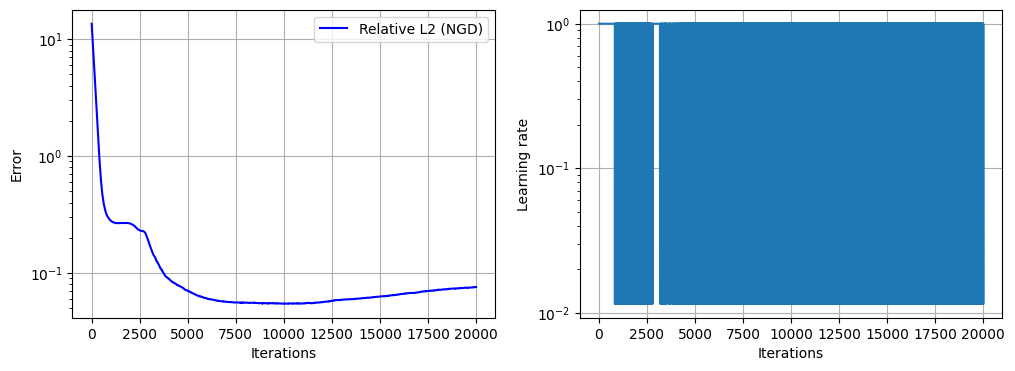

In [39]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot NGD losses
val_losses = jnp.asarray(val_losses)

axes[0].semilogy(jnp.arange(len(val_losses)), jnp.sqrt(val_losses/y_val_norm), label="Relative L2 (NGD)", color="blue")

axes[0].grid()
axes[0].legend()
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Error")

# plot learning rates
axes[1].semilogy(learning_rates)
axes[1].grid()
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Learning rate")

In [ ]:
def gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                    val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                    optimizer: optax.GradientTransformation,
                    params: list[TT],
                    opt_steps: int,
                    training_key: PRNGKeyArray,
                    batch_size: int = 64,
                    backtracking: bool = False) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []
    
    @jax.jit
    def step(tensors: list[TT],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"]):
        loss, grads = jax.value_and_grad(compute_loss)(tensors, x, y)
        if backtracking:
            updates, opt_state = optimizer.update(grads, opt_state, tensors, value=loss, grad=grads, value_fn=lambda p: compute_loss(p, x,y))
        else:
            updates, opt_state = optimizer.update(grads, opt_state, tensors)
        params = optax.apply_updates(tensors, updates)
        return params, opt_state, loss

    learning_rates = []
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y)
        val_loss = compute_loss(params, X_val, y_val)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if backtracking:
            learning_rates.append(opt_state[1].learning_rate)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses), learning_rates

In [ ]:
optimizer = optax.chain(
    optax.adam(learning_rate=1.),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=20)
    optax.scale_by_zoom_linesearch(max_linesearch_steps=20, initial_guess_strategy="keep")
)

params_gd, (train_losses_gd, val_losses_gd), learning_rates_gd = gradient_descent(train_dataset=(X_train, y_train),
                                                                              val_dataset=(X_val, y_val),
                                                                              optimizer=optimizer,
                                                                              params=init_controls,
                                                                              opt_steps=40_000,
                                                                              training_key=training_key,
                                                                              batch_size=128,
                                                                              backtracking=True)

Iter 0 | Loss: 1.471e-01 | Val loss: 7.981e-02
Iter 5 | Loss: 1.958e-02 | Val loss: 1.657e-02
Iter 10 | Loss: 1.322e-02 | Val loss: 1.220e-02
Iter 15 | Loss: 1.001e-02 | Val loss: 7.326e-03
Iter 20 | Loss: 4.201e-03 | Val loss: 3.875e-03
Iter 25 | Loss: 3.246e-03 | Val loss: 3.404e-03
Iter 30 | Loss: 3.084e-03 | Val loss: 3.339e-03
Iter 35 | Loss: 3.201e-03 | Val loss: 3.294e-03
Iter 40 | Loss: 3.401e-03 | Val loss: 3.186e-03
Iter 45 | Loss: 2.586e-03 | Val loss: 2.937e-03
Iter 50 | Loss: 2.767e-03 | Val loss: 2.640e-03
Iter 55 | Loss: 2.846e-03 | Val loss: 2.457e-03
Iter 60 | Loss: 2.398e-03 | Val loss: 2.010e-03
Iter 65 | Loss: 1.445e-03 | Val loss: 1.425e-03
Iter 70 | Loss: 8.513e-04 | Val loss: 1.011e-03
Iter 75 | Loss: 8.270e-04 | Val loss: 8.885e-04
Iter 80 | Loss: 9.412e-04 | Val loss: 7.844e-04
Iter 85 | Loss: 7.970e-04 | Val loss: 7.599e-04
Iter 90 | Loss: 9.706e-04 | Val loss: 7.605e-04
Iter 95 | Loss: 6.999e-04 | Val loss: 7.186e-04
Iter 100 | Loss: 7.090e-04 | Val loss: 7.2

Text(0, 0.5, 'Learning rate')

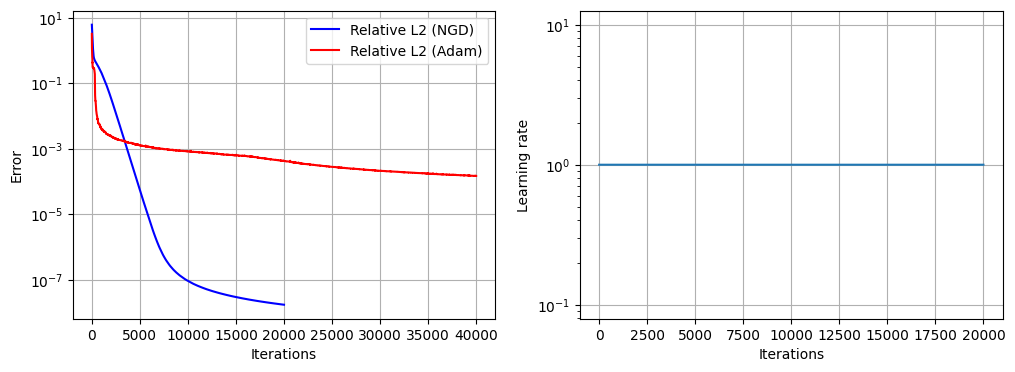

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot NGD losses
val_losses_ng = jnp.asarray(val_losses)
val_losses_gd = jnp.asarray(val_losses_gd)

axes[0].semilogy(jnp.arange(len(val_losses_ng)), jnp.sqrt(val_losses_ng/y_val_norm), label="Relative L2 (NGD)", color="blue")
axes[0].semilogy(jnp.arange(len(val_losses_gd)), jnp.sqrt(val_losses_gd/y_val_norm), label="Relative L2 (Adam)", color="red")

axes[0].grid()
axes[0].legend()
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Error")

# plot learning rates
axes[1].semilogy(learning_rates)
axes[1].grid()
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Learning rate")

In [ ]:
jnp.save("tt_ngd.npy", jnp.sqrt(val_losses_ng/y_val_norm))
jnp.save("tt_adam.npy", jnp.sqrt(val_losses_gd/y_val_norm))